In [188]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error

In [187]:
df = pd.read_csv("/mnt/scratch/sameer/test_rosetta/Output/score.sc",
                 delim_whitespace=True, skiprows=1)
print(df.columns)
df

Index(['SCORE:', 'total_score', 'Grid_score', 'Transform_accept_ratio',
       'angle_constraint', 'atom_pair_constraint', 'chainbreak',
       'classic_grid_X', 'coordinate_constraint', 'dihedral_constraint',
       'dslf_ca_dih', 'dslf_cs_ang', 'dslf_ss_dih', 'dslf_ss_dst', 'fa_atr',
       'fa_dun', 'fa_elec', 'fa_pair', 'fa_rep', 'fa_sol', 'hbond_bb_sc',
       'hbond_lr_bb', 'hbond_sc', 'hbond_sr_bb', 'if_X_angle_constraint',
       'if_X_atom_pair_constraint', 'if_X_chainbreak',
       'if_X_coordinate_constraint', 'if_X_dihedral_constraint',
       'if_X_dslf_ca_dih', 'if_X_dslf_cs_ang', 'if_X_dslf_ss_dih',
       'if_X_dslf_ss_dst', 'if_X_fa_atr', 'if_X_fa_dun', 'if_X_fa_elec',
       'if_X_fa_pair', 'if_X_fa_rep', 'if_X_fa_sol', 'if_X_hbond_bb_sc',
       'if_X_hbond_lr_bb', 'if_X_hbond_sc', 'if_X_hbond_sr_bb', 'if_X_omega',
       'if_X_p_aa_pp', 'if_X_pro_close', 'if_X_ref', 'interface_delta_X',
       'ligand_is_touching_X', 'omega', 'p_aa_pp', 'pro_close', 'ref',
       't

,SCORE:,total_score,Grid_score,Transform_accept_ratio,angle_constraint,atom_pair_constraint,chainbreak,classic_grid_X,coordinate_constraint,dihedral_constraint,...,if_X_pro_close,if_X_ref,interface_delta_X,ligand_is_touching_X,omega,p_aa_pp,pro_close,ref,total_score_X,description
0,SCORE:,-871.747,-31.0,0.46,0.0,0.0,0.0,-25.0,0.700,0.0,...,0.0,0.0,-8.200,1.0,49.388,-40.567,1.272,-43.83,-25.0,SadA_NSLeu_1ALA.pdb
1,SCORE:,-874.571,-31.0,0.54,0.0,0.0,0.0,-31.0,1.017,0.0,...,0.0,0.0,-10.123,1.0,49.877,-40.458,1.257,-43.83,-31.0,SadA_NSLeu_1ALA.pdb
2,SCORE:,-872.553,-31.0,0.58,0.0,0.0,0.0,-30.0,0.725,0.0,...,0.0,0.0,-6.888,1.0,49.387,-40.750,1.288,-43.83,-30.0,SadA_NSLeu_1ALA.pdb
3,SCORE:,-872.404,-31.0,0.59,0.0,0.0,0.0,-29.0,0.401,0.0,...,0.0,0.0,-12.197,1.0,49.407,-40.608,1.261,-43.83,-29.0,SadA_NSLeu_1ALA.pdb
4,SCORE:,-871.007,-31.0,0.57,0.0,0.0,0.0,-30.0,0.472,0.0,...,0.0,0.0,-7.499,1.0,49.242,-40.545,1.261,-43.83,-30.0,SadA_NSLeu_1ALA.pdb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SCORE:,-870.494,-31.0,0.51,0.0,0.0,0.0,-28.0,0.896,0.0,...,0.0,0.0,-10.192,1.0,49.434,-40.532,1.246,-43.83,-28.0,SadA_NSLeu_1ALA.pdb
4996,SCORE:,-872.398,-31.0,0.67,0.0,0.0,0.0,-24.0,0.875,0.0,...,0.0,0.0,-9.515,1.0,49.398,-40.764,1.247,-43.83,-24.0,SadA_NSLeu_1ALA.pdb
4997,SCORE:,-870.912,-31.0,0.55,0.0,0.0,0.0,-23.0,0.759,0.0,...,0.0,0.0,-6.923,1.0,49.431,-40.660,1.263,-43.83,-23.0,SadA_NSLeu_1ALA.pdb
4998,SCORE:,-867.497,-31.0,0.57,0.0,0.0,0.0,-24.0,0.558,0.0,...,0.0,0.0,-6.448,1.0,49.249,-40.555,1.257,-43.83,-24.0,SadA_NSLeu_1ALA.pdb


Spearman r between total_score and interface_delta_X : 0.69


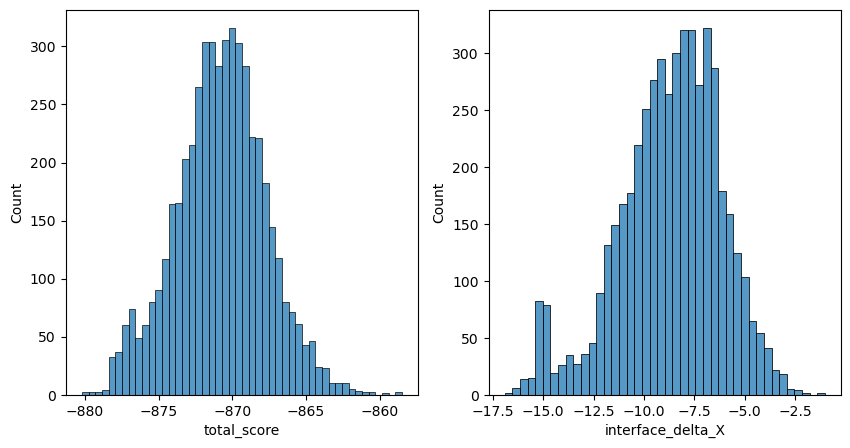

In [197]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
sns.histplot(df.total_score, ax=axs[0])
sns.histplot(df.interface_delta_X, ax=axs[1])


print(f"Spearman r between total_score and interface_delta_X : "
      f"{spearmanr(df.total_score, df.interface_delta_X).statistic:.2f}")
      
pass

In [16]:
np.random.seed(100)

In [198]:
sample_size = 4000
num_samples = 200

In [199]:
def pick_mininmum(arr, sample_size, arr2=None):
    """ Select sample_size elements of arr at random and return the minimum m
        if arr2 is not None, also return the value of arr2 in the same place as m
    """
    N = len(arr)
    sample_idxs = np.random.choice(np.arange(N), size=sample_size, replace=False)
    #print(sample_idxs)
    m = arr[sample_idxs].argmin()
    ret = arr[sample_idxs].iloc[m]
    if arr2 is not None:
        assert(len(arr) == len(arr2))
        ret = (ret, arr2[sample_idxs].iloc[m])
    return ret

In [230]:
all_results = []

for sample_size in (1, 5, 10, 100, 500, 1000, 2000):
    x_mins = np.zeros(num_samples, dtype=float)
    y_mins = np.zeros_like(x_mins)
    for i in range(num_samples):
        x_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size)
        y_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size)
    results_df = pd.DataFrame({"sample_size":np.repeat(sample_size, num_samples),
                               "i":np.arange(num_samples), "x_mins":x_mins, "y_mins":y_mins})    
    all_results.append(results_df)
all_results = pd.concat(all_results)

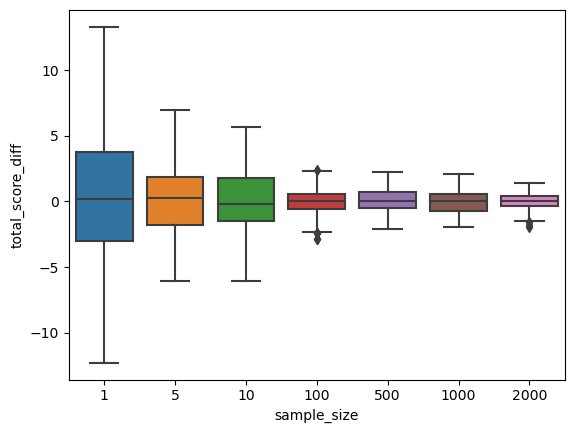

In [232]:
all_results["total_score_diff"] = all_results.y_mins - all_results.x_mins
sns.boxplot(all_results, x="sample_size", y="total_score_diff", )
pass

In [239]:
all_results = []

for sample_size in (1, 5, 10, 100, 500, 1000, 2000):
    x_mins = np.zeros(num_samples, dtype=float)
    y_mins = np.zeros_like(x_mins)
    for i in range(num_samples):
        x_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size, 
                                      arr2=df.interface_delta_X)[1]
        y_mins[i] = pick_mininmum(df.total_score, sample_size=sample_size,
                                     arr2=df.interface_delta_X)[1]
    results_df = pd.DataFrame({"sample_size":np.repeat(sample_size, num_samples),
                               "i":np.arange(num_samples), "x_mins":x_mins, "y_mins":y_mins})    
    all_results.append(results_df)
all_results = pd.concat(all_results)

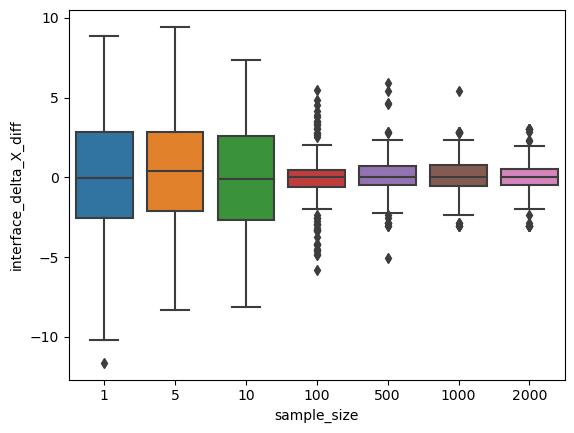

In [240]:
all_results["interface_delta_X_diff"] = all_results.y_mins - all_results.x_mins
sns.boxplot(all_results, x="sample_size", y="interface_delta_X_diff", )
pass